In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

In [3]:
df = pd.read_csv('CC GENERAL.csv')
data = df.drop('CUST_ID', axis=1)

In [4]:
imputer = SimpleImputer(strategy='median')
data_imputed = imputer.fit_transform(data)

In [5]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_imputed)

In [6]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.1

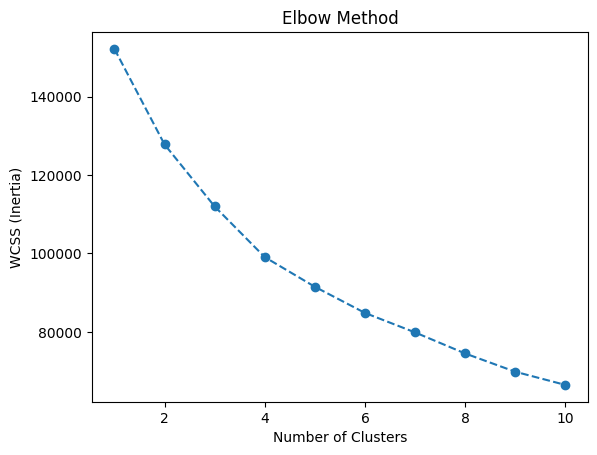

In [7]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Inertia)')
plt.show()

In [8]:
from sklearn.decomposition import PCA

In [9]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

In [10]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


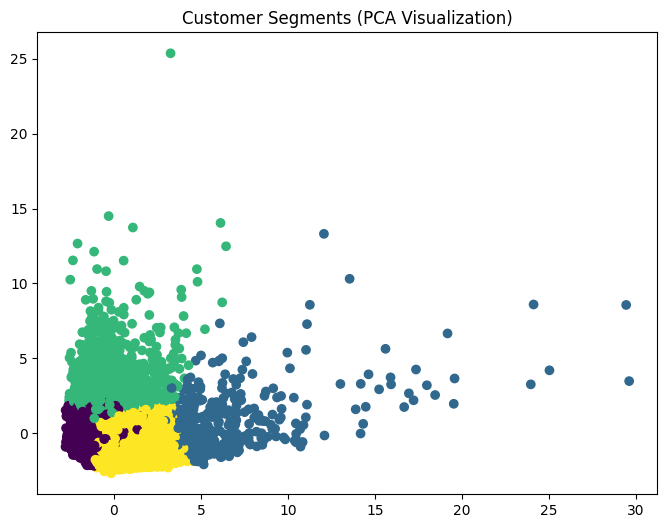

In [11]:
plt.figure(figsize=(8,6))
plt.scatter(pca_data[:,0], pca_data[:,1], c=clusters, cmap='viridis')
plt.title('Customer Segments (PCA Visualization)')
plt.show()

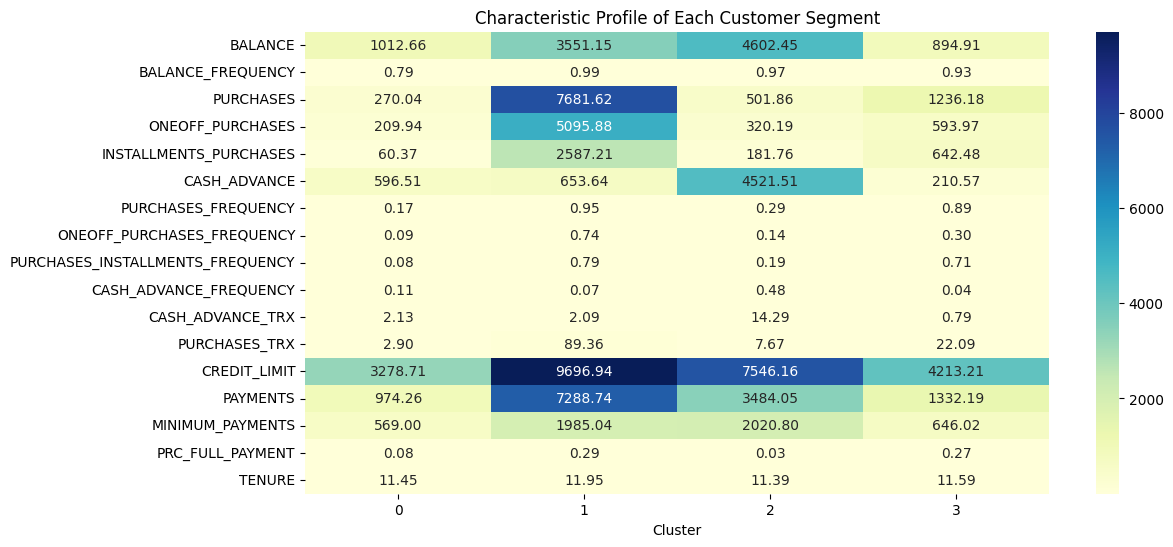

In [ ]:
import seaborn as sns

df['Cluster'] = clusters

cluster_profile = df.drop('CUST_ID', axis=1).groupby('Cluster').mean()

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_profile.T, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Characteristic Profile of Each Customer Segment')
plt.show()